<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transfer Learning using Pre-trained CNN**
# Objective:
To apply transfer learning using ResNet/VGG.


## 1. Load Dataset

In [3]:
# FAST DEBUG VERSION — Transfer Learning (MobileNetV2)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print("Loading CIFAR-10...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# USE SMALL DATASET (FAST DEBUGGING)
x_train = x_train[:5000]
y_train = y_train[:5000]
x_test  = x_test[:1000]
y_test  = y_test[:1000]

# Resize (FAST)
x_train = tf.image.resize(x_train, (64, 64))
x_test  = tf.image.resize(x_test,  (64, 64))

x_train = tf.cast(x_train, tf.float32)
x_test  = tf.cast(x_test,  tf.float32)

# Preprocess
x_train = preprocess_input(x_train)
x_test  = preprocess_input(x_test)

# Labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print(f"Train: {x_train.shape} | Test: {x_test.shape}")

Loading CIFAR-10...
Train: (5000, 64, 64, 3) | Test: (1000, 64, 64, 3)


## 2. Data Pipeline (FAST)

In [4]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .shuffle(1000) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

## 3. Load MobileNetV2

In [5]:
print("Loading MobileNetV2...")
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

base_model.trainable = False

Loading MobileNetV2...


/tmp/ipykernel_32082/797831021.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


## 4. Build Model

In [6]:
inputs = tf.keras.Input(shape=(64, 64, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

## 5. Compile

In [7]:
model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Train

In [8]:
print("\nTraining (FAST MODE)...")

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    verbose=1
)


Training (FAST MODE)...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.4610 - loss: 1.6193 - val_accuracy: 0.6020 - val_loss: 1.1256
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.6312 - loss: 1.0626 - val_accuracy: 0.6320 - val_loss: 1.0537
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.6984 - loss: 0.8507 - val_accuracy: 0.6470 - val_loss: 1.0429
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.7528 - loss: 0.7085 - val_accuracy: 0.6420 - val_loss: 1.0312
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7834 - loss: 0.6191 - val_accuracy: 0.6480 - val_loss: 1.0429


## 7. Evaluate

In [9]:
loss, acc = model.evaluate(test_ds)
print(f"\nFinal Accuracy: {acc*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.6480 - loss: 1.0429

Final Accuracy: 64.80%


## 8. Plot

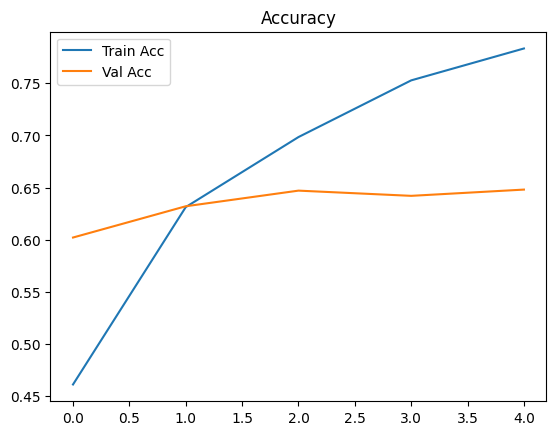

In [10]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.show()